In [5]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 3.3 MB/s eta 0:00:00


In [6]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0).total_memory/1024**3,"GB")

True
Tesla T4
14.56219482421875 GB


In [11]:
from pathlib import Path

dataset = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2")

print("Train:", len(list((dataset/"images/train").glob("*.jpg"))))
print("Val:", len(list((dataset/"images/val").glob("*.jpg"))))
print("Test:", len(list((dataset/"images/test").glob("*.jpg"))))

Train: 15549
Val: 1944
Test: 1944


In [12]:
import yaml

data = {
    "path": "/kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["cyclone"]
}

with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml created successfully!")

data.yaml created successfully!


In [16]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")
model.info()

YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.8 GFLOPs


(181, 9458752, 0, 21.8363392)

In [17]:
results = model.train(

    data="/kaggle/working/data.yaml",

    epochs=20,

    imgsz=640,

    batch=32,

    workers=4,

    device=0,

    optimizer="AdamW",

    lr0=0.001,

    weight_decay=0.0005,

    patience=3,

    cos_lr=True,

    amp=True,

    project="CycloneYOLO",

    name="YOLO11s",

    pretrained=True,

    verbose=True,

    plots=True
)

Ultralytics 8.4.131 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11s-4, nbs=64, nms=False, opset

In [18]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.131 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 198.7±68.5 MB/s, size: 125.4 KB)
val: Scanning /kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/labels/val... 1944 images, 105 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1944/1944 1.0Kit/s 1.9s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 122/122 4.5it/s 27.2s0.2s
                   all       1944       1883      0.929      0.993      0.992      0.837
Speed: 1.0ms preprocess, 10.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with 

In [20]:
model = YOLO("/kaggle/working/runs/detect/CycloneYOLO/YOLO11s-4/weights/best.pt")

In [22]:
results = model.predict(
    source="/kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/images/test",
    conf=0.25,
    save=True,
    imgsz=640
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1944 /kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/images/test/negative_000012.jpg: 640x640 (no detections), 15.5ms
image 2/1944 /kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/images/test/negative_000014.jpg: 640x640 (no detections), 15.4ms
image 3/1944 /kaggle/input/datasets/punitkashyap2007/cyclone-dataset-yolo/final_dataset_v2/images/test/negative_000020.jpg: 640x640 (no detections)

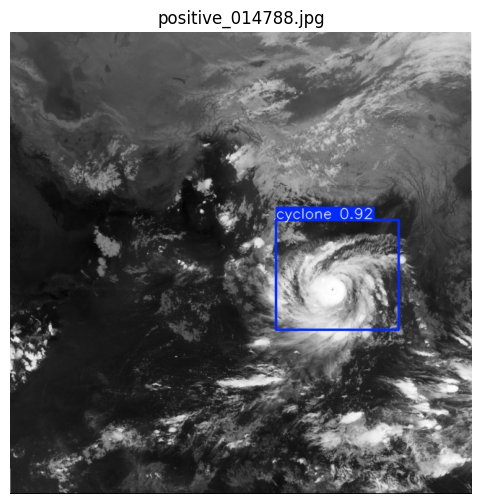

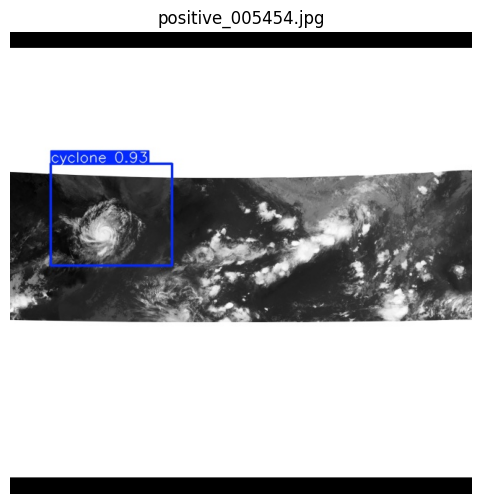

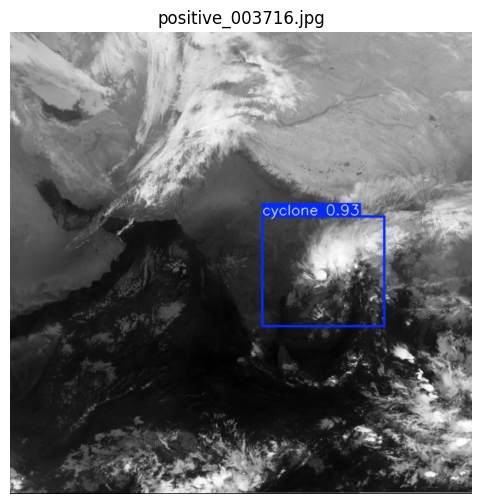

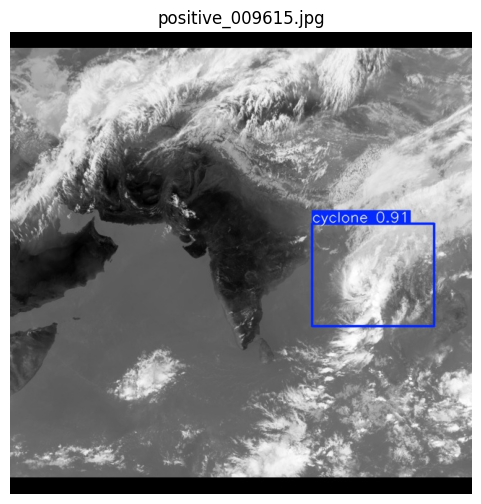

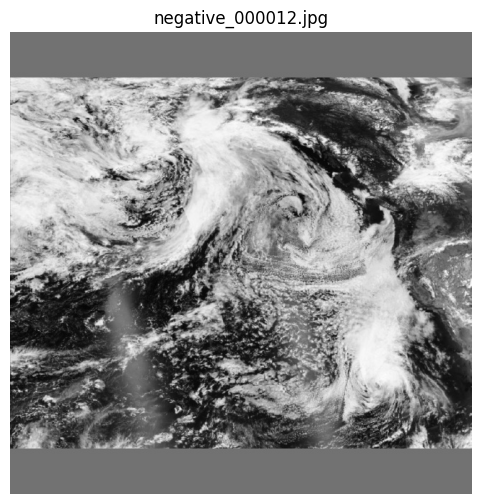

In [28]:
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path

preds = list(Path("runs/detect/predict").glob("*.jpg"))

for img_path in random.sample(preds, min(5, len(preds))):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

In [26]:
import shutil
from pathlib import Path

BEST_MODEL = Path("/kaggle/working/runs/detect/CycloneYOLO/YOLO11s-4/weights/best.pt")
SAVE_DIR = Path("/kaggle/working/final_model")

SAVE_DIR.mkdir(exist_ok=True)

shutil.copy2(BEST_MODEL, SAVE_DIR / "cyclone_yolo11s_best.pt")

print("Model saved successfully!")

Model saved successfully!


In [27]:
import shutil

shutil.make_archive(
    "/kaggle/working/cyclone_yolo11s_model",
    "zip",
    "/kaggle/working/final_model"
)

print("Model ZIP created!")

Model ZIP created!
